# Analisis Sentimen Ulasan Produk Tokopedia 2025

Notebook ini mencakup pengambilan data, eksplorasi, preprocessing teks bahasa Indonesia, pelatihan Logistic Regression, evaluasi, dan prediksi sentimen.

## 1. Persiapan lingkungan

In [1]:
%pip install -q kagglehub Sastrawi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.7 MB/s eta 0:00:00


In [2]:
import re
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

RANDOM_STATE = 42
LABELS = ["negative", "neutral", "positive"]
sns.set_theme(style="whitegrid")


## 2. Memuat dataset

In [3]:
dataset_dir = Path(kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025"))
csv_path = next(dataset_dir.glob("*.csv"))
df = pd.read_csv(csv_path)

print(f"Dataset: {csv_path.name}")
print(f"Ukuran: {df.shape[0]:,} baris × {df.shape[1]} kolom")
display(df.head())

100%|██████████| 3.54M/3.54M [00:01<00:00, 3.22MB/s]

Extracting files...


Dataset: tokopedia_product_reviews_2025.csv
Ukuran: 65,543 baris × 13 kolom


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()
display(df.describe(include="all"))
display(df.isna().sum().rename("missing_values"))
display(df["rating"].value_counts().sort_index().rename("jumlah"))
display(df["sentiment_label"].value_counts().rename("jumlah"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
count,65543,65543,6.554300e+04,65543,65543,26749,6.554300e+04,65543,6.554300e+04,65543.000000,65543.000000,6.554300e+04,65543
unique,58068,2845,NaN,5418,6,5511,NaN,5521,NaN,NaN,NaN,NaN,3
top,Bagus,2024-10-03,NaN,Chosamon Mid Top Original Sepatu Sneakers Olah...,Makanan & Minuman,Default,NaN,https://www.tokopedia.com/indofarmproduct/telu...,NaN,NaN,NaN,NaN,positive
freq,323,83,NaN,80,17859,1733,NaN,20,NaN,NaN,NaN,NaN,63943
mean,NaN,NaN,9.814143e+08,NaN,NaN,NaN,5.421295e+05,NaN,2.447482e+10,4.893764,1954.923897,7.615674e+16,NaN
std,NaN,NaN,4.193324e+08,NaN,NaN,NaN,2.365557e+06,NaN,3.870717e+10,0.492495,18244.026827,7.516573e+17,NaN
min,NaN,NaN,1.027202e+07,NaN,NaN,NaN,1.000000e+02,NaN,4.298375e+06,1.000000,6.000000,6.050000e+02,NaN
25%,NaN,NaN,7.182240e+08,NaN,NaN,NaN,2.990000e+04,NaN,1.446882e+09,5.000000,100.000000,2.298522e+06,NaN
50%,NaN,NaN,9.740048e+08,NaN,NaN,NaN,8.000000e+04,NaN,4.769575e+09,5.000000,500.000000,5.801280e+06,NaN
75%,NaN,NaN,1.145967e+09,NaN,NaN,NaN,2.146870e+05,NaN,1.534605e+10,5.000000,1000.000000,9.061811e+06,NaN


,missing_values
review_text,0
review_date,0
review_id,0
product_name,0
product_category,0
product_variant,38794
product_price,0
product_url,0
product_id,0
rating,0


,jumlah
rating,
1,547
2,251
3,802
4,2418
5,61525


,jumlah
sentiment_label,
positive,63943
neutral,802
negative,798


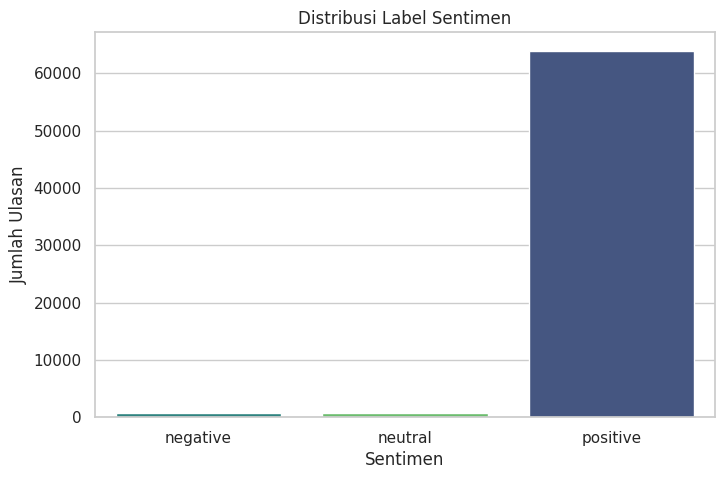

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="sentiment_label",
    order=LABELS,
    hue="sentiment_label",
    palette="viridis",
    legend=False,
)
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

## 4. Preprocessing teks

In [6]:
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return stopword_remover.remove(text)

sample_text = df["review_text"].dropna().iloc[0]
print("Sebelum:", sample_text)
print("Sesudah:", clean_text(sample_text))

Sebelum: baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller
Sesudah: baru sekali terima brg dr belanja online dg packing super rapih aman semula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp ternyata packing liar biasa rapi aman kerem seller


In [7]:
stemmer = StemmerFactory().create_stemmer()

def clean_text_advanced(text):
    return stemmer.stem(clean_text(text))

print(f"Sebelum stemming: {sample_text[:50]}...")
print(f"Sesudah stemming: {clean_text_advanced(sample_text)}")


Sebelum stemming: baru sekali ini terima brg dr belanja online dg pa...
Sesudah stemming: baru sekali terima brg dr belanja online dg packing super rapih aman mula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp nyata packing liar biasa rapi aman rem seller


## 5. Pelatihan model

In [8]:
n_samples = 700
balanced_parts = []

for label in LABELS:
    group = df[df["sentiment_label"] == label]
    balanced_parts.append(
        group.sample(
            n=n_samples,
            replace=len(group) < n_samples,
            random_state=RANDOM_STATE,
        )
    )

df_balanced = pd.concat(balanced_parts, ignore_index=True)
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

tfidf = TfidfVectorizer(max_features=2_000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 6. Evaluasi model

              precision    recall  f1-score   support

    negative       0.61      0.61      0.61       140
     neutral       0.54      0.53      0.53       140
    positive       0.82      0.83      0.83       140

    accuracy                           0.66       420
   macro avg       0.66      0.66      0.66       420
weighted avg       0.66      0.66      0.66       420



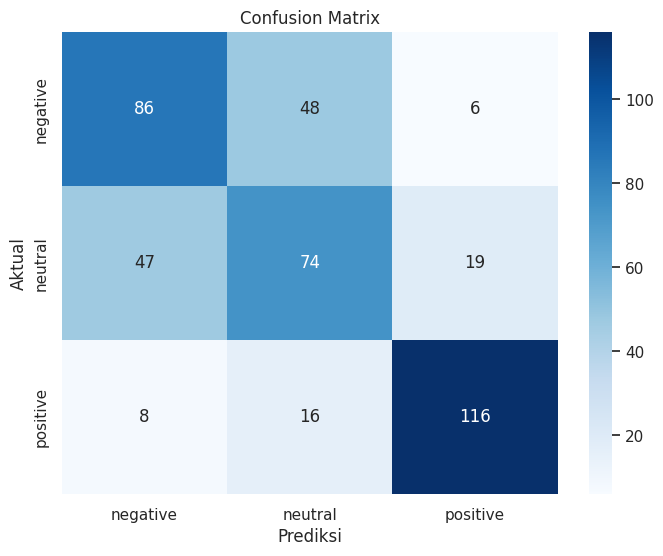

In [9]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

## 7. Optimasi model


In [10]:
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text_advanced)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]
)
param_grid = {
    "tfidf__max_features": [1_000, 2_000, 3_000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1_macro",
)
grid_search.fit(X_train, y_train)

print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Skor CV terbaik: {grid_search.best_score_:.4f}")


Parameter terbaik: {'clf__C': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Skor CV terbaik: 0.6565


In [11]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("Hasil setelah tuning")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        labels=LABELS,
        zero_division=0,
    )
)


Hasil setelah tuning
              precision    recall  f1-score   support

    negative       0.59      0.60      0.60       140
     neutral       0.54      0.51      0.52       140
    positive       0.80      0.84      0.82       140

    accuracy                           0.65       420
   macro avg       0.64      0.65      0.65       420
weighted avg       0.64      0.65      0.65       420



### 10. Pengembangan: Menggunakan Seluruh Dataset dengan Class Weighting

Alih-alih undersampling, kita akan menggunakan lebih banyak data dan menangani ketidakseimbangan label menggunakan parameter `class_weight`.

In [14]:
from sklearn.utils import class_weight
import numpy as np

# 1. Gunakan dataset original (df) yang sudah di-clean
# Agar cepat, kita ambil subset yang lebih besar (misal 10.000 baris)
df_large = df.sample(n=min(10000, len(df)), random_state=RANDOM_STATE)
df_large['clean_text'] = df_large['review_text'].apply(clean_text)

# 2. Split data
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    df_large['clean_text'],
    df_large['sentiment_label'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_large['sentiment_label']
)

# 3. Pipeline dengan Logistic Regression (class_weight='balanced')
pipeline_balanced = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,1))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

# 4. Training
pipeline_balanced.fit(X_train_l, y_train_l)

# 5. Evaluasi
y_pred_l = pipeline_balanced.predict(X_test_l)
print("Laporan Klasifikasi (Dengan Seluruh Data & Balanced Weights):")
print(classification_report(y_test_l, y_pred_l, labels=LABELS))

Laporan Klasifikasi (Dengan Seluruh Data & Balanced Weights):
              precision    recall  f1-score   support

    negative       0.18      0.36      0.24        25
     neutral       0.09      0.27      0.14        26
    positive       0.99      0.95      0.97      1949

    accuracy                           0.93      2000
   macro avg       0.42      0.53      0.45      2000
weighted avg       0.97      0.93      0.95      2000



## 11. Implementasi IndoBERT (Deep Learning)

Kita akan menggunakan model `indobenchmark/indobert-base-p2` yang telah dilatih khusus untuk bahasa Indonesia.

In [15]:
%pip install -q transformers datasets torch

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 1. Inisialisasi Model dan Tokenizer
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Mapping label ke ID
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)

def tokenize_function(examples):
    return tokenizer(examples["review_text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizer dan Model IndoBERT berhasil dimuat.")

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer dan Model IndoBERT berhasil dimuat.


Selanjutnya, kita akan menyiapkan data dalam format `datasets` agar kompatibel dengan proses training Hugging Face.

In [17]:
# Menyiapkan subset data untuk demo training cepat
# Kita gunakan df_balanced yang sudah kita buat sebelumnya agar distribusi kelas merata
train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=RANDOM_STATE)

# Konversi ke HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['review_text', 'sentiment_label']])
val_dataset = Dataset.from_pandas(val_df[['review_text', 'sentiment_label']])

# Map label string ke integer
train_dataset = train_dataset.map(lambda x: {'labels': label2id[x['sentiment_label']]})
val_dataset = val_dataset.map(lambda x: {'labels': label2id[x['sentiment_label']]})

# Tokenisasi
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

print("Dataset siap untuk proses fine-tuning.")

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

Dataset siap untuk proses fine-tuning.


### 12. Fine-Tuning IndoBERT

Kita akan melatih model selama 3 epoch. Pastikan Anda menggunakan runtime GPU (Edit > Notebook settings > Hardware accelerator: T4 GPU) agar proses ini berjalan cepat.

In [5]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import os

# Mematikan peringatan token jika tidak diperlukan
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 0. Definisi Label
LABELS = ["negative", "neutral", "positive"]

# 1. Inisialisasi Model dan Tokenizer
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)

# 2. Fungsi Metrik
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 3. Konfigurasi Training
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    report_to="none"
)

# 4. Inisialisasi Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Memulai training IndoBERT (proses ini memakan waktu beberapa menit)... updates akan muncul di bawah.")
trainer.train()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NameError: name 'train_dataset' is not defined

### 12. Fine-Tuning IndoBERT

Kita akan melatih model selama 3 epoch. Pastikan Anda menggunakan runtime GPU (Edit > Notebook settings > Hardware accelerator: T4 GPU) agar proses ini berjalan cepat.

In [19]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import TrainingArguments, Trainer

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Memulai training...")
trainer.train()

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

### 12. Fine-Tuning IndoBERT

Kita akan melatih model selama 3 epoch. Pastikan Anda menggunakan runtime GPU (Edit > Notebook settings > Hardware accelerator: T4 GPU) agar proses ini berjalan cepat.

In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Memulai training...")
trainer.train()

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

Setelah training selesai, kita bisa mengevaluasi hasilnya untuk melihat apakah skor F1 meningkat dibandingkan model Logistic Regression sebelumnya.

## 8. Visualisasi kata dominan

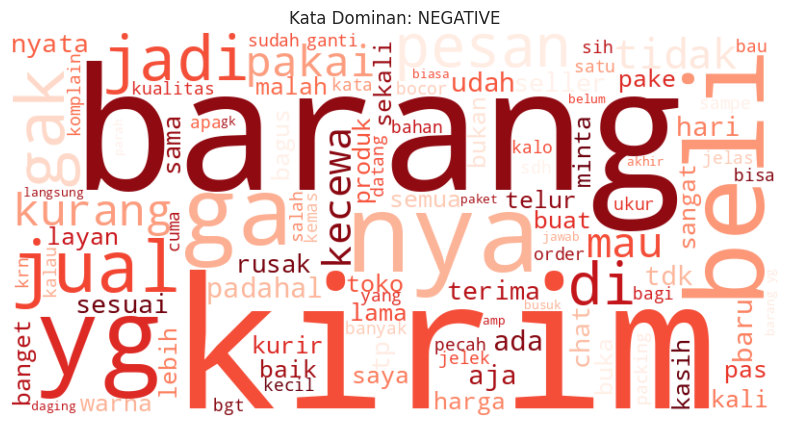

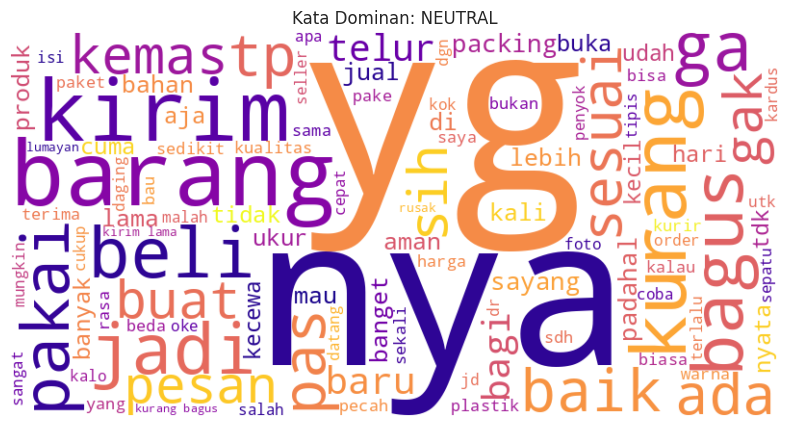

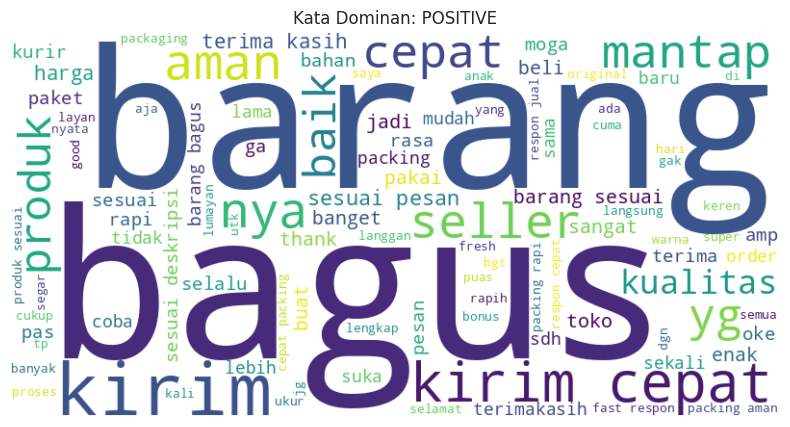

In [12]:
def show_wordcloud(sentiment, colormap):
    text = " ".join(
        df_balanced.loc[
            df_balanced["sentiment_label"] == sentiment, "clean_text"
        ]
    )
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Kata Dominan: {sentiment.upper()}")
    plt.show()

for sentiment, colormap in zip(LABELS, ["Reds", "plasma", "viridis"]):
    show_wordcloud(sentiment, colormap)

## 9. Prediksi ulasan baru

In [13]:
def prediksi_sentimen(teks):
    teks_bersih = clean_text(teks)
    vektor = tfidf.transform([teks_bersih])
    return model.predict(vektor)[0]

contoh_ulasan = [
    "Barangnya rusak saat sampai",
    "Bagus banget, pengiriman cepat",
    "Biasa saja, lumayan",
]

for ulasan in contoh_ulasan:
    print(f"{ulasan!r}: {prediksi_sentimen(ulasan)}")

'Barangnya rusak saat sampai': negative
'Bagus banget, pengiriman cepat': positive
'Biasa saja, lumayan': neutral
